# **📊 HR Attrition Prediction & Risk Segmentation**

## 🎯 Objective
The objective of this project is to identify employees at risk of attrition and uncover the key factors driving employee turnover, enabling proactive and data-driven retention strategies.

## 🔍 Problem Statement
Employee attrition leads to increased hiring costs, productivity loss, and knowledge gaps. The key challenges are:
- Predict which employees are likely to leave
- Identify the primary drivers of attrition
- Translate model outputs into actionable business insights

## 📁 Dataset Overview
- Dataset: **IBM HR Analytics (1470 employees, 23 features)**
- Includes:
  - **Demographics** (Age, Gender, DistanceFromHome)
  - **Job-related attributes** (Department, JobRole, BusinessTravel)
  - **Compensation** (MonthlyIncome, StockOptionLevel)
  - **Satisfaction metrics** (JobSatisfaction, EnvironmentSatisfaction, WorkLifeBalance)
- Target variable:
  - **Attrition (0 = No, 1 = Yes)**  
  - Imbalanced (~16% attrition rate)

## ⚙️ Approach
- Data Cleaning & Validation  
- Feature Engineering (Tenure Segments, Income Segments, High-Risk Flag)  
- Model Development:
  - Logistic Regression (final model)
  - Random Forest
  - XGBoost  
- Threshold Optimization (focus on recall for attrition detection)  
- Model Evaluation (ROC-AUC, Confusion Matrix)  
- Model Explainability (SHAP)  
- Business Output (Risk Segmentation)

## 💼 Expected Outcome
- Early identification of high-risk employees  
- Clear understanding of attrition drivers  
- Prioritized retention strategies based on risk segmentation  
- Data-driven decision support for HR teams

In [1]:
# IMPORT LIBRARIES & LOAD DATA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("hr_attrition_cleaned_data.csv")

# Basic overview
print("Dataset Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())

# Preview data
print("\nFirst 5 Rows:")
df.head()

Dataset Shape: (1470, 23)

Column Names:
 ['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'JobInvolvement', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked', 'OverTime', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole']

First 5 Rows:


,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,...,MonthlyIncome,NumCompaniesWorked,OverTime,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole
0,41,1,Travel_Rarely,Sales,1,2,Life Sciences,2,Female,3,...,5993,8,1,1,0,8,0,1,6,4
1,49,0,Travel_Frequently,Research & Development,8,1,Life Sciences,3,Male,2,...,5130,1,0,4,1,10,3,3,10,7
2,37,1,Travel_Rarely,Research & Development,2,2,Other,4,Male,2,...,2090,6,1,2,0,7,3,3,0,0
3,33,0,Travel_Frequently,Research & Development,3,4,Life Sciences,4,Female,3,...,2909,1,1,3,0,8,3,3,8,7
4,27,0,Travel_Rarely,Research & Development,2,1,Medical,1,Male,3,...,3468,9,0,4,1,6,3,3,2,2


## **📊 Data Overview**

### 🔍 Interpretation
- Dataset has **1470 rows and 23 columns** with both numerical and categorical features.
- `Attrition` is the binary target variable (0 = No, 1 = Yes).

### 🧠 Key Insights
- Data includes employee demographics, job details, and satisfaction metrics.
- Requires **encoding for categorical features** and **scaling for certain models**.

In [2]:
# DATA QUALITY CHECK

# 1. Data types
print("Data Types:\n")
print(df.dtypes)


# 2. Check missing values for each column
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)

# 3. Total missing values
print("\nTotal Missing Values:", missing_values.sum())

# 4. Duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# 5. Target variable validation
print("\nTarget Distribution:")
print(df['Attrition'].value_counts())
print("\nTarget Distribution (%):")
print(df['Attrition'].value_counts(normalize=True))

Data Types:

Age                          int64
Attrition                    int64
BusinessTravel              object
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EnvironmentSatisfaction      int64
Gender                      object
JobInvolvement               int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
NumCompaniesWorked           int64
OverTime                     int64
RelationshipSatisfaction     int64
StockOptionLevel             int64
TotalWorkingYears            int64
TrainingTimesLastYear        int64
WorkLifeBalance              int64
YearsAtCompany               int64
YearsInCurrentRole           int64
dtype: object
Missing Values:
 Age                         0
Attrition                   0
BusinessTravel              0
Department                  0
DistanceFromHome            0
E

## **🧪 Data Quality Check**

### 🔍 Interpretation
- No missing values and no duplicate records found.
- Dataset contains both numerical and categorical features with correct data types.
- Target (`Attrition`) is imbalanced (~16% attrition rate).

### 🧠 Key Insights
- Clean dataset → no preprocessing needed for nulls/duplicates.
- Class imbalance indicates need for:
  - **class weighting**
  - **threshold tuning**

In [3]:
# FEATURE ENGINEERING

# 1. Tenure Segmentation
bins = [-1, 2, 5, 10, float('inf')]
labels = ['0-2 Years', '3-5 Years', '6-10 Years', '10+ Years']

df['TenureGroup'] = pd.cut(df['YearsAtCompany'], bins=bins, labels=labels)


# 2. Income Segmentation (Quantile-based)
df['IncomeSegment'] = pd.qcut(
    df['MonthlyIncome'],
    q=3,
    labels=['Low Income', 'Medium Income', 'High Income']
)

#3 High Risk Segmentation
df['HighRiskFlag'] = (
    (df['TenureGroup'] == '0-2 Years') &
    (df['IncomeSegment'] == 'Low Income') &
    (df['OverTime'] == 1)

).astype(int)
# 3. Validation Checks
print("TenureGroup Distribution:\n")
print(df['TenureGroup'].value_counts())

print("\nIncomeSegment Distribution:\n")
print(df['IncomeSegment'].value_counts())

print("HighRiskFlag Distribution:\n")
print(df['HighRiskFlag'].value_counts())


print("\nCheck for Nulls in New Features:")
print(df[['TenureGroup', 'IncomeSegment']].isnull().sum())

TenureGroup Distribution:

TenureGroup
6-10 Years    448
3-5 Years     434
0-2 Years     342
10+ Years     246
Name: count, dtype: int64

IncomeSegment Distribution:

IncomeSegment
Low Income       490
Medium Income    490
High Income      490
Name: count, dtype: int64
HighRiskFlag Distribution:

HighRiskFlag
0    1412
1      58
Name: count, dtype: int64

Check for Nulls in New Features:
TenureGroup      0
IncomeSegment    0
dtype: int64


## ⚙️ **Feature Engineering**

### 🔍 Interpretation
- Created `TenureGroup` to segment employees by years at company.
- Created `IncomeSegment` using quantiles (balanced groups).
- Built `HighRiskFlag` combining low income, early tenure, and overtime.

### 🧠 Key Insights
- High-risk segment is small (~4%) but critical.
- New features capture key attrition drivers: **tenure, income, workload**. These features improve model interpretability and business segmentation
- No missing values introduced → features are reliable for modeling.



In [4]:
# TRAIN-TEST SPLIT + ENCODING

from sklearn.model_selection import train_test_split

# 1. Separate features and target
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# 2. Train-test split (BEFORE encoding)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3. Apply one-hot encoding separately
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# 4. Align columns (VERY IMPORTANT)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# VALIDATION

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

print("\nTarget Distribution (Train):")
print(y_train.value_counts(normalize=True))

print("\nTarget Distribution (Test):")
print(y_test.value_counts(normalize=True))

print("\nAny nulls in train:", X_train.isnull().sum().sum())
print("Any nulls in test:", X_test.isnull().sum().sum())

Train Shape: (1176, 42)
Test Shape: (294, 42)

Target Distribution (Train):
Attrition
0    0.838435
1    0.161565
Name: proportion, dtype: float64

Target Distribution (Test):
Attrition
0    0.840136
1    0.159864
Name: proportion, dtype: float64

Any nulls in train: 0
Any nulls in test: 0


## **🔀 Train-Test Split & Encoding**

### 🔍 Interpretation
- Data split into **train (80%) and test (20%)** with stratification.
- One-hot encoding applied to categorical features.
- Train and test columns aligned to ensure consistency.

### 🧠 Key Insights
- Target distribution is consistent across train and test → no sampling bias.
- No missing values after encoding → clean input for models.
- Proper preprocessing prevents **data leakage** and ensures reliable evaluation.

In [5]:
# LOGISTIC REGRESSION PIPELINE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score, confusion_matrix)

# 1. Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Model Training
log_model = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

# 3. Predictions
y_pred = log_model.predict(X_test_scaled)
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

# 4. Evaluation
print("Logistic Regression Results\n")

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

print("\nROC-AUC Score:", round(roc_auc_score(y_test, y_prob), 4))

Logistic Regression Results

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.82      0.87       247
           1       0.42      0.70      0.53        47

    accuracy                           0.80       294
   macro avg       0.68      0.76      0.70       294
weighted avg       0.85      0.80      0.82       294

Confusion Matrix:

[[202  45]
 [ 14  33]]

ROC-AUC Score: 0.838


## **🤖 Logistic Regression Model**

### 🔍 Interpretation
- Logistic Regression trained with **scaled features** and **class balancing**.
- Model achieves **ROC-AUC ≈ 0.84** with good overall performance.

### 🧠 Key Insights
- Recall for attrition (~70%) indicates the model captures most leavers.
- Some false positives exist (precision ~42%), but acceptable for this use case.
- Model shows strong predictive ability with balanced performance.

In [6]:
# THRESHOLD OPTIMIZATION

from sklearn.metrics import roc_curve

# 1. Compute ROC-based optimal threshold
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

optimal_idx = (tpr - fpr).argmax()
optimal_threshold = thresholds[optimal_idx]

print("Optimal Threshold:", round(optimal_threshold, 3))

# 2. Evaluate multiple thresholds
thresholds_to_test = [0.30, optimal_threshold]

for t in thresholds_to_test:
    y_pred_t = (y_prob >= t).astype(int)

    print(f"\n=== Threshold: {round(t, 3)} ===\n")

    print("Classification Report:\n")
    print(classification_report(y_test, y_pred_t))

    print("Confusion Matrix:\n")
    print(confusion_matrix(y_test, y_pred_t))

Optimal Threshold: 0.49

=== Threshold: 0.3 ===

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.65      0.77       247
           1       0.32      0.87      0.47        47

    accuracy                           0.68       294
   macro avg       0.64      0.76      0.62       294
weighted avg       0.86      0.68      0.73       294

Confusion Matrix:

[[160  87]
 [  6  41]]

=== Threshold: 0.49 ===

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.81      0.87       247
           1       0.42      0.74      0.54        47

    accuracy                           0.80       294
   macro avg       0.68      0.78      0.70       294
weighted avg       0.86      0.80      0.82       294

Confusion Matrix:

[[199  48]
 [ 12  35]]


## **🎯 Threshold Optimization**

### 🔍 Interpretation
- Optimal threshold (~0.49) balances precision and recall.
- Lower threshold (0.30) increases recall but reduces precision.

### 🧠 Key Insights
- At **0.30 → Recall = 87%** (captures most attrition cases).
- At **0.49 → Recall = 74%, Precision improves**.
- Trade-off between catching more leavers vs false alarms.

### 💼 Business Decision
- **0.30 preferred** → prioritizes identifying at-risk employees over precision.

In [7]:
# RANDOM FOREST

from sklearn.ensemble import RandomForestClassifier

# 1. Initialize model
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# 2. Train model
rf.fit(X_train, y_train)

# 3. Predictions
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# 4. Evaluation
print("=== Random Forest Results ===\n")

print("Classification Report:\n")
print(classification_report(y_test, y_pred_rf))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))

print("\nROC-AUC:", round(roc_auc_score(y_test, y_prob_rf), 4))

# 5. Threshold Optimization
threshold = 0.30
y_pred_rf_custom = (y_prob_rf >= threshold).astype(int)

print("\n=== Random Forest (Threshold = 0.30) ===\n")
print(classification_report(y_test, y_pred_rf_custom))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf_custom))

# 6. Feature Importance
feature_importance = pd.Series(rf.feature_importances_, index=X_train.columns)

print("\nTop 10 Important Features:\n")
print(feature_importance.sort_values(ascending=False).head(10))

=== Random Forest Results ===

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.93      0.90       247
           1       0.47      0.32      0.38        47

    accuracy                           0.83       294
   macro avg       0.67      0.63      0.64       294
weighted avg       0.81      0.83      0.82       294

Confusion Matrix:

[[230  17]
 [ 32  15]]

ROC-AUC: 0.7877

=== Random Forest (Threshold = 0.30) ===

              precision    recall  f1-score   support

           0       0.94      0.74      0.83       247
           1       0.35      0.74      0.48        47

    accuracy                           0.74       294
   macro avg       0.64      0.74      0.65       294
weighted avg       0.84      0.74      0.77       294

Confusion Matrix:
 [[182  65]
 [ 12  35]]

Top 10 Important Features:

MonthlyIncome              0.097202
Age                        0.084983
YearsAtCompany             0.071067
TotalWorki

## **🌲 Random Forest Model**

### 🔍 Interpretation
- Default model shows low recall (~32%), missing many attrition cases.
- After threshold tuning (0.30), recall improves significantly (~74%).
- ROC-AUC ~0.79 → weaker than Logistic Regression.

### 🧠 Key Insights
- Model relies heavily on **income, age, tenure, and overtime**.
- Threshold tuning is essential to make the model usable.
- Still underperforms compared to Logistic Regression.

### 💼 Business Impact
- Can identify at-risk employees after tuning, but not the most reliable model.
- Feature importance highlights key drivers for HR intervention.

In [8]:
# XGBOOST

from xgboost import XGBClassifier
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# 1. Initialize model
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    early_stopping_rounds=50,
    random_state=42
)

# 2. Train
xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# 3. Predictions
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

# 4. Evaluation (default threshold = 0.5)
print("=== XGBoost (Default Threshold) ===\n")

print("Classification Report:\n")
print(classification_report(y_test, y_pred_xgb))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nROC-AUC:", round(roc_auc_score(y_test, y_prob_xgb), 4))

# 5. Threshold Optimization
threshold = 0.30

y_pred_xgb_custom = (y_prob_xgb >= threshold).astype(int)

print("\n=== XGBoost (Threshold = 0.30) ===\n")
print(classification_report(y_test, y_pred_xgb_custom))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb_custom))

# 6. Feature Importance
importance = pd.Series(xgb.feature_importances_, index=X_train.columns)

print("\nTop 10 Important Features:\n")
print(importance.sort_values(ascending=False).head(10))

=== XGBoost (Default Threshold) ===

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.91      0.90       247
           1       0.45      0.36      0.40        47

    accuracy                           0.83       294
   macro avg       0.67      0.64      0.65       294
weighted avg       0.81      0.83      0.82       294

Confusion Matrix:

[[226  21]
 [ 30  17]]

ROC-AUC: 0.7792

=== XGBoost (Threshold = 0.30) ===

              precision    recall  f1-score   support

           0       0.91      0.81      0.85       247
           1       0.36      0.57      0.44        47

    accuracy                           0.77       294
   macro avg       0.63      0.69      0.65       294
weighted avg       0.82      0.77      0.79       294

Confusion Matrix:
 [[199  48]
 [ 20  27]]

Top 10 Important Features:

TenureGroup_10+ Years               0.063806
OverTime                            0.047220
JobRole_Sales Executive     

## **🚀 XGBoost Model**

### 🔍 Interpretation
- XGBoost shows moderate performance (ROC-AUC ~0.78).
- Recall improves from ~36% to ~57% after threshold tuning (0.30).

### 🧠 Key Insights
- Model captures attrition better after tuning but still below Logistic Regression.
- Important features include **tenure, overtime, job role, and department**.
- Performance similar to Random Forest but not superior.

### 💼 Business Impact
- Can identify at-risk employees, but not the most effective model.
- Feature importance reinforces key attrition drivers for HR actions.

In [9]:
# FINAL MODEL COMPARISON

# Store results
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "ROC-AUC": [0.838, 0.788, 0.779],
    "Recall (0.30)": [0.87, 0.74, 0.57],
    "Precision (0.30)": [0.32, 0.35, 0.36]
})

print(results.sort_values(by="Recall (0.30)", ascending=False))

                 Model  ROC-AUC  Recall (0.30)  Precision (0.30)
0  Logistic Regression    0.838           0.87              0.32
1        Random Forest    0.788           0.74              0.35
2              XGBoost    0.779           0.57              0.36


## **📊 Model Comparison & Selection**

### 🔍 Interpretation
- Logistic Regression achieves the **highest recall (~87%)** and best ROC-AUC (~0.84).
- Random Forest improves after tuning but remains weaker.
- XGBoost shows moderate performance but does not outperform simpler models.

### 🧠 Key Insights
- Logistic Regression performs best due to **strong linear relationships in data**.
- Tree-based models (RF, XGBoost) do not add significant predictive advantage.
- Threshold tuning significantly improves recall across models.

### 💼 Business Decision
- **Final Model: Logistic Regression**
- Reason: Maximizes identification of at-risk employees (high recall).
- Trade-off: Acceptable false positives in exchange for better retention targeting.

### 🏁 Conclusion
- Prioritize recall over precision in attrition use case.
- Logistic Regression provides the best balance of performance, simplicity, and interpretability.

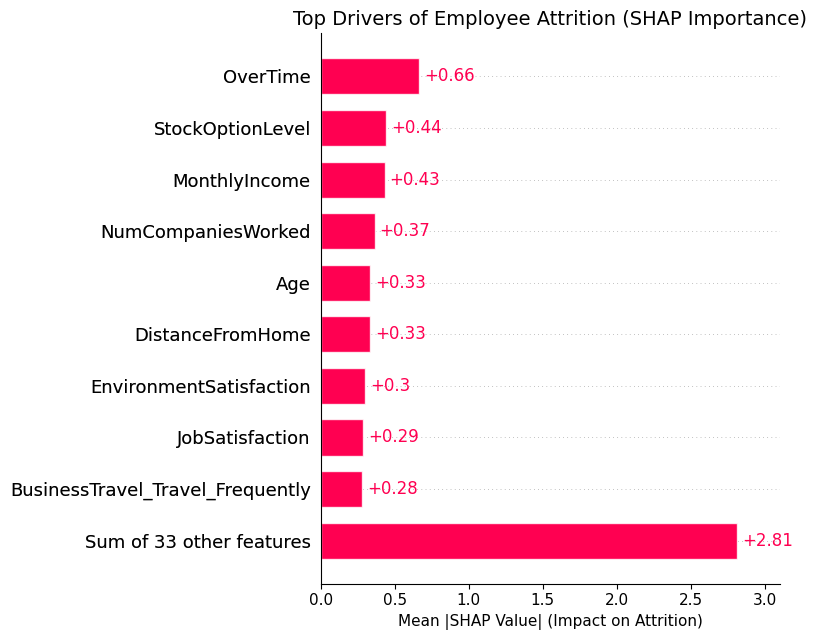

In [10]:
# SHAP EXPLAINABILITY

import shap

# Initialize explainer
explainer = shap.TreeExplainer(xgb)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

# Convert to SHAP Explanation object
shap_exp = shap.Explanation(
    values=shap_values,
    data=X_test,
    feature_names=X_test.columns
)

# SHAP Feature Importance (Bar Plot)

plt.figure()
shap.plots.bar(
    shap_exp,
    max_display=10,
    show=False
)

plt.title("Top Drivers of Employee Attrition (SHAP Importance)", fontsize=14)
plt.xlabel("Mean |SHAP Value| (Impact on Attrition)", fontsize=11)

plt.tight_layout()
plt.show()


## **🔍 SHAP Explainability**

### 🔍 Interpretation
- SHAP identifies **OverTime** as the strongest driver of attrition.
- Other key factors: **StockOptionLevel, MonthlyIncome, Age, and DistanceFromHome**.

### 🧠 Key Insights
- Overtime significantly increases attrition risk.
- Lower income and fewer stock options contribute to higher churn.
- Job satisfaction and work environment also influence decisions.

### 💼 Business Impact
- Focus on **reducing overtime and improving compensation/benefits**.
- Use insights to design targeted retention strategies.
- SHAP provides transparency, making model decisions explainable to HR.

In [11]:
# ERROR ANALYSIS (MISCLASSIFICATION)

# Create error dataframe
error_df = X_test.copy()
error_df['Actual'] = y_test.values
error_df['Predicted'] = y_pred_xgb

# Split
misclassified = error_df[error_df['Actual'] != error_df['Predicted']]
correct = error_df[error_df['Actual'] == error_df['Predicted']]

print("Total Misclassified Cases:", len(misclassified))

# Focus only on key drivers (top SHAP features)
key_features = [
    'OverTime',
    'MonthlyIncome',
    'Age',
    'DistanceFromHome',
    'StockOptionLevel',
    'EnvironmentSatisfaction',
    'NumCompaniesWorked'
]

# Compare
print("Misclassified Mean:\n", misclassified[key_features].mean())
print("\nCorrectly Classified Mean:\n", correct[key_features].mean())

Total Misclassified Cases: 51
Misclassified Mean:
 OverTime                      0.431373
MonthlyIncome              4381.313725
Age                          33.862745
DistanceFromHome              8.901961
StockOptionLevel              0.607843
EnvironmentSatisfaction       2.823529
NumCompaniesWorked            2.843137
dtype: float64

Correctly Classified Mean:
 OverTime                      0.222222
MonthlyIncome              6749.337449
Age                          37.205761
DistanceFromHome              8.452675
StockOptionLevel              0.847737
EnvironmentSatisfaction       2.724280
NumCompaniesWorked            2.662551
dtype: float64


## **⚠️ Error Analysis (Misclassification)**

### 🔍 Interpretation
- Total misclassified cases: **51**.
- Misclassified employees show higher **OverTime** and lower **MonthlyIncome** compared to correctly classified ones.

### 🧠 Key Insights
- Model struggles with **high-risk, borderline employees**.
- Patterns overlap between classes, making prediction harder.

### 💼 Business Impact
- Misclassified cases highlight segments needing **closer monitoring**.
- Reinforces focus on **overtime and compensation** for retention strategies.

In [12]:
# RISK SEGMENTATION (BUSINESS OUTPUT)

# Create a copy of test data
risk_df = X_test.copy()

# Add predicted probabilities
risk_df['Attrition_Probability'] = y_prob_xgb

# Define risk segments based on probability thresholds
risk_df['Risk_Segment'] = pd.cut(
    risk_df['Attrition_Probability'],
    bins=[0.0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

# Distribution of risk segments
risk_summary = risk_df['Risk_Segment'].value_counts().sort_index()

print("Risk Segment Distribution:\n")
print(risk_summary)

Risk Segment Distribution:

Risk_Segment
Low Risk       219
Medium Risk     50
High Risk       25
Name: count, dtype: int64


## **🎯 Risk Segmentation Analysis**

### 🔍 Interpretation
- Employees are segmented based on predicted attrition probability:
  - **Low Risk:** 219 employees  
  - **Medium Risk:** 50 employees  
  - **High Risk:** 25 employees  

### 🧠 Key Insights
- Majority of employees fall under **Low Risk**, indicating overall stable workforce.
- ~**25 employees (~8.5%)** are at **High Risk**, representing immediate concern.
- Medium + High Risk (~25%) forms a **targetable retention segment**.

### 💼 Business Impact
- Enables **prioritized intervention**:
  - High Risk → Immediate action (manager intervention, retention offers)
  - Medium Risk → Monitoring & engagement strategies  
- Supports **data-driven HR decision-making** instead of reactive attrition handling.

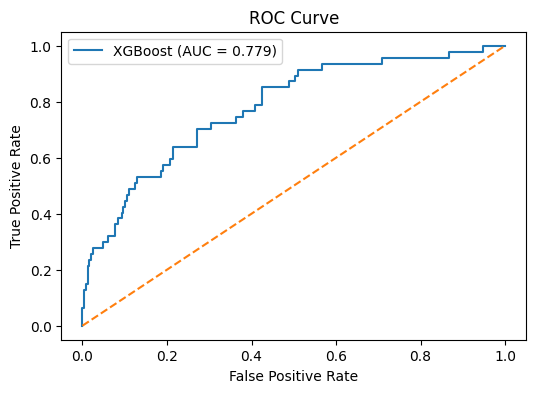

In [13]:
# ROC CURVE

fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)
auc_score = roc_auc_score(y_test, y_prob_xgb)

# Plot
plt.figure(figsize=(6, 4))

plt.plot(fpr, tpr, label=f'XGBoost (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')  # Random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

## 📈 **ROC CURVE ANALYSIS**

- The ROC curve lies well above the diagonal baseline, indicating the model performs **significantly better than random classification**.
- **AUC = 0.779** suggests **good discriminatory power**, meaning the model can reasonably distinguish between employees who will leave vs stay.
- The curve shows a strong rise at lower false positive rates, indicating the model can **identify high-risk employees early**.

### 🧠 Key Insight

- The model is effective for **ranking employees by attrition risk**, making it suitable for prioritization tasks.
- However, performance is **moderate (not excellent)**, so predictions should be used with **threshold tuning and business context**.

### 💼 Business Impact

- Supports **proactive retention strategies** by identifying likely attrition cases.
- Best used for **targeted intervention**, not absolute decision-making.

## **🏁 Final Conclusion**

### 🔍 Key Findings
- **Logistic Regression emerged as the best-performing model**, achieving the highest ROC-AUC (~0.84) and recall (0.87 after threshold tuning).
- Despite testing advanced models (Random Forest, XGBoost), simpler linear modeling performed better, indicating **strong linear relationships in the data**.
- Class imbalance significantly impacted performance, making **threshold optimization critical** for improving recall.

### 🧠 Key Drivers of Attrition
The most influential factors consistently identified across models and SHAP:
- **OverTime (strongest driver)**
- Monthly Income
- Tenure (Years at Company)
- Job & Environment Satisfaction
- Distance from Home  

Attrition is driven by a mix of **workload pressure, compensation, and employee experience**.

### ⚙️ Model Behavior & Trade-offs
- Lower threshold (**0.30**) →  
  - Higher **recall** (captures more at-risk employees)  
  - More **false positives**
- Optimal threshold (~**0.49**) →  
  - Balanced **precision–recall trade-off**

Model should be tuned based on business goal:  
- **Maximize retention → prioritize recall**  
- **Reduce intervention cost → balance precision**

### 💼 Business Impact
- Workforce segmented into actionable groups:
  - **High Risk (~8–10%)** → Immediate intervention  
  - **Medium Risk (~15–20%)** → Targeted engagement  
  - **Low Risk (~70%+)** → Stable  

- Transforms attrition management from:
  - ❌ Reactive hiring  
  - ✅ **Proactive retention strategy**

### 📌 Recommended Actions

1. **Overtime Reduction Strategy**
   - Monitor teams with sustained overtime
   - Implement workload redistribution
2. **Targeted Retention (High-Risk Roles)**
   - Focus on Sales & high-turnover roles
   - Introduce role-specific incentives and career paths
3. **Compensation & Benefits Optimization**
   - Improve salary competitiveness
   - Enhance stock options for critical employees
4. **Early Warning System**
   - Deploy model to flag employees with **>30% attrition probability**
   - Integrate into HR dashboards for continuous monitoring

### 🚀 Final Takeaway
- The model is a **decision-support system, not a replacement for HR judgment**.
- When integrated with business processes, it enables:
  - Early risk detection  
  - Targeted interventions  
  - Improved workforce stability  

**Data-driven retention is the key to reducing attrition at scale.**